# 🎙️ Speech Emotion Recognition

## Task 2 — Data Exploration

This notebook performs complete exploratory data analysis on the RAVDESS speech emotion dataset.

### Objectives

- Explore the dataset structure
- Count total audio samples
- Identify emotion classes
- Analyze emotion distribution
- Analyze actor-wise distribution
- Analyze audio duration
- Analyze sample rates
- Play sample audio
- Visualize waveform
- Visualize Mel spectrogram
- Visualize MFCC
- Compare waveforms across emotions
- Compare spectrograms across emotions

---

### Dataset

RAVDESS — Ryerson Audio-Visual Database of Emotional Speech and Song.

In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

from IPython.display import Audio, display

warnings.filterwarnings("ignore")

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 1. Dataset Configuration

The dataset is stored in:

`dataset/RAVDESS/`

The notebook searches recursively for all `.wav` files.

In [2]:
# ------------------------------------------------------------
# Dataset path
# ------------------------------------------------------------

DATASET_PATH = "../dataset/RAVDESS"

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset not found:\n{os.path.abspath(DATASET_PATH)}"
    )

print("✓ Dataset found")
print(
    "Path:",
    os.path.abspath(DATASET_PATH)
)

✓ Dataset found
Path: c:\Users\harsh\OneDrive\Desktop\CodeAlpha_EmotionRecognition\dataset\RAVDESS


In [3]:
# ------------------------------------------------------------
# Find all WAV files
# ------------------------------------------------------------

audio_files = sorted(
    glob.glob(
        os.path.join(
            DATASET_PATH,
            "**",
            "*.wav"
        ),
        recursive=True
    )
)

print(
    f"Total audio files: {len(audio_files):,}"
)

print("\nFirst 10 files:")

for file in audio_files[:10]:
    print(file)

Total audio files: 1,440

First 10 files:
../dataset/RAVDESS\Actor_01\03-01-01-01-01-01-01.wav
../dataset/RAVDESS\Actor_01\03-01-01-01-01-02-01.wav
../dataset/RAVDESS\Actor_01\03-01-01-01-02-01-01.wav
../dataset/RAVDESS\Actor_01\03-01-01-01-02-02-01.wav
../dataset/RAVDESS\Actor_01\03-01-02-01-01-01-01.wav
../dataset/RAVDESS\Actor_01\03-01-02-01-01-02-01.wav
../dataset/RAVDESS\Actor_01\03-01-02-01-02-01-01.wav
../dataset/RAVDESS\Actor_01\03-01-02-01-02-02-01.wav
../dataset/RAVDESS\Actor_01\03-01-02-02-01-01-01.wav
../dataset/RAVDESS\Actor_01\03-01-02-02-01-02-01.wav


In [4]:
audio_files = glob.glob(
    os.path.join(
        DATASET_PATH,
        "**",
        "*.wav"
    ),
    recursive=True
)

print(
    f"Total audio files: {len(audio_files)}"
)

print("\nlast 10 files:")

for file in audio_files[-10:]:
    print(file)

Total audio files: 1440

last 10 files:
../dataset/RAVDESS\Actor_24\03-01-07-02-02-01-24.wav
../dataset/RAVDESS\Actor_24\03-01-07-02-02-02-24.wav
../dataset/RAVDESS\Actor_24\03-01-08-01-01-01-24.wav
../dataset/RAVDESS\Actor_24\03-01-08-01-01-02-24.wav
../dataset/RAVDESS\Actor_24\03-01-08-01-02-01-24.wav
../dataset/RAVDESS\Actor_24\03-01-08-01-02-02-24.wav
../dataset/RAVDESS\Actor_24\03-01-08-02-01-01-24.wav
../dataset/RAVDESS\Actor_24\03-01-08-02-01-02-24.wav
../dataset/RAVDESS\Actor_24\03-01-08-02-02-01-24.wav
../dataset/RAVDESS\Actor_24\03-01-08-02-02-02-24.wav


## 2. Emotion Labels

RAVDESS filenames use the following emotion codes:

| Code | Emotion |
|------|---------|
| 01 | neutral |
| 02 | calm |
| 03 | happy |
| 04 | sad |
| 05 | angry |
| 06 | fearful |
| 07 | disgust |
| 08 | surprised |

The emotion code is extracted from the third section of the filename.

In [5]:
EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}


def parse_filename(file_path):

    filename = os.path.basename(file_path)

    parts = filename.replace(
        ".wav",
        ""
    ).split("-")

    if len(parts) != 7:
        return None

    modality = parts[0]
    vocal_channel = parts[1]
    emotion_code = parts[2]
    intensity = parts[3]
    statement = parts[4]
    repetition = parts[5]
    actor = parts[6]

    return {
        "filename": filename,
        "file_path": file_path,
        "modality": modality,
        "vocal_channel": vocal_channel,
        "emotion_code": emotion_code,
        "emotion": EMOTION_MAP.get(
            emotion_code,
            "unknown"
        ),
        "intensity": intensity,
        "statement": statement,
        "repetition": repetition,
        "actor": int(actor)
    }


records = []

for file in audio_files:

    parsed = parse_filename(file)

    if parsed is not None:
        records.append(parsed)


df = pd.DataFrame(records)

print(
    f"✓ Parsed records: {len(df):,}"
)

df.head()

✓ Parsed records: 1,440


,filename,file_path,modality,vocal_channel,emotion_code,emotion,intensity,statement,repetition,actor
0,03-01-01-01-01-01-01.wav,../dataset/RAVDESS\Actor_01\03-01-01-01-01-01-...,03,01,01,neutral,01,01,01,1
1,03-01-01-01-01-02-01.wav,../dataset/RAVDESS\Actor_01\03-01-01-01-01-02-...,03,01,01,neutral,01,01,02,1
2,03-01-01-01-02-01-01.wav,../dataset/RAVDESS\Actor_01\03-01-01-01-02-01-...,03,01,01,neutral,01,02,01,1
3,03-01-01-01-02-02-01.wav,../dataset/RAVDESS\Actor_01\03-01-01-01-02-02-...,03,01,01,neutral,01,02,02,1
4,03-01-02-01-01-01-01.wav,../dataset/RAVDESS\Actor_01\03-01-02-01-01-01-...,03,01,02,calm,01,01,01,1


In [7]:
EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}


def parse_filename(file_path):

    filename = os.path.basename(file_path)

    parts = filename.replace(
        ".wav",
        ""
    ).split("-")

    if len(parts) != 7:
        return None

    modality = parts[0]
    vocal_channel = parts[1]
    emotion_code = parts[2]
    intensity = parts[3]
    statement = parts[4]
    repetition = parts[5]
    actor = parts[6]

    return {
        "filename": filename,
        "file_path": file_path,
        "modality": modality,
        "vocal_channel": vocal_channel,
        "emotion_code": emotion_code,
        "emotion": EMOTION_MAP.get(
            emotion_code,
            "unknown"
        ),
        "intensity": intensity,
        "statement": statement,
        "repetition": repetition,
        "actor": int(actor)
    }


records = []

for file in audio_files:

    parsed = parse_filename(file)

    if parsed is not None:
        records.append(parsed)


df = pd.DataFrame(records)

print(
    f"✓ Parsed records: {len(df):,}"
)

df.tail()

✓ Parsed records: 1,440


,filename,file_path,modality,vocal_channel,emotion_code,emotion,intensity,statement,repetition,actor
1435,03-01-08-01-02-02-24.wav,../dataset/RAVDESS\Actor_24\03-01-08-01-02-02-...,03,01,08,surprised,01,02,02,24
1436,03-01-08-02-01-01-24.wav,../dataset/RAVDESS\Actor_24\03-01-08-02-01-01-...,03,01,08,surprised,02,01,01,24
1437,03-01-08-02-01-02-24.wav,../dataset/RAVDESS\Actor_24\03-01-08-02-01-02-...,03,01,08,surprised,02,01,02,24
1438,03-01-08-02-02-01-24.wav,../dataset/RAVDESS\Actor_24\03-01-08-02-02-01-...,03,01,08,surprised,02,02,01,24
1439,03-01-08-02-02-02-24.wav,../dataset/RAVDESS\Actor_24\03-01-08-02-02-02-...,03,01,08,surprised,02,02,02,24


## 3. Dataset Information

In [8]:
print("Dataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(
    df.isnull().sum()
)

print("\nDataset information:")
df.info()

Dataset shape:
(1440, 10)

Columns:
['filename', 'file_path', 'modality', 'vocal_channel', 'emotion_code', 'emotion', 'intensity', 'statement', 'repetition', 'actor']

Missing values:
filename         0
file_path        0
modality         0
vocal_channel    0
emotion_code     0
emotion          0
intensity        0
statement        0
repetition       0
actor            0
dtype: int64

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   filename       1440 non-null   str  
 1   file_path      1440 non-null   str  
 2   modality       1440 non-null   str  
 3   vocal_channel  1440 non-null   str  
 4   emotion_code   1440 non-null   str  
 5   emotion        1440 non-null   str  
 6   intensity      1440 non-null   str  
 7   statement      1440 non-null   str  
 8   repetition     1440 non-null   str  
 9   actor          1440 non-null

In [9]:
print("Emotion classes:")

for emotion in sorted(
    df["emotion"].unique()
):
    print(
        " -",
        emotion
    )

print(
    "\nNumber of emotion classes:",
    df["emotion"].nunique()
)

Emotion classes:
 - angry
 - calm
 - disgust
 - fearful
 - happy
 - neutral
 - sad
 - surprised

Number of emotion classes: 8


# 📊 Graph 1 — Emotion Distribution

This graph shows the number of audio samples available for each emotion.

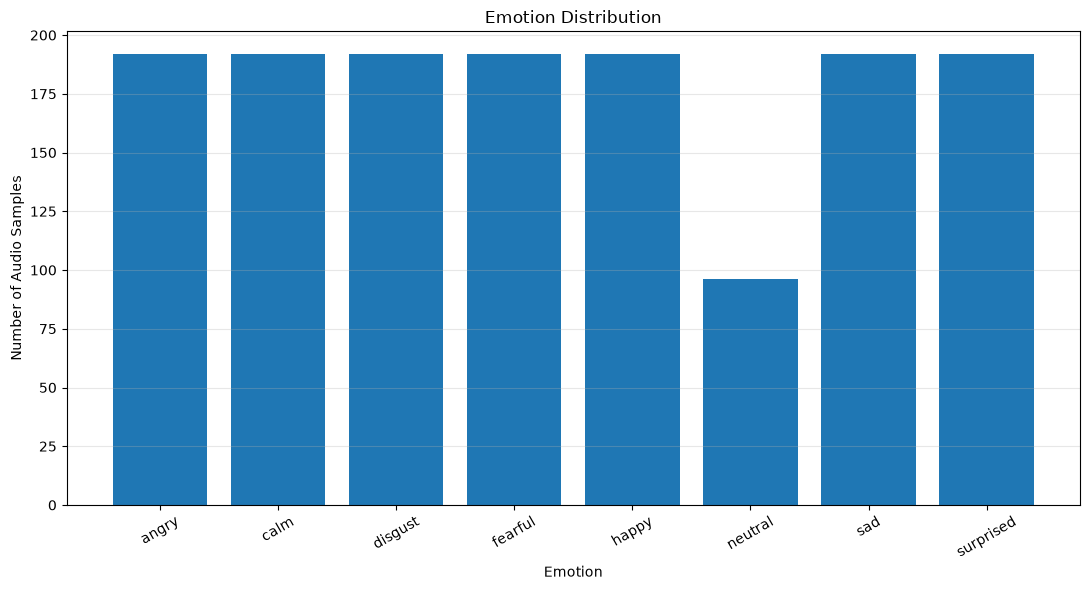

In [10]:
emotion_counts = (
    df["emotion"]
    .value_counts()
    .sort_index()
)

plt.figure(
    figsize=(11, 6)
)

plt.bar(
    emotion_counts.index,
    emotion_counts.values
)

plt.title(
    "Emotion Distribution"
)

plt.xlabel(
    "Emotion"
)

plt.ylabel(
    "Number of Audio Samples"
)

plt.xticks(
    rotation=30
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

# 🥧 Graph 2 — Emotion Percentage Distribution

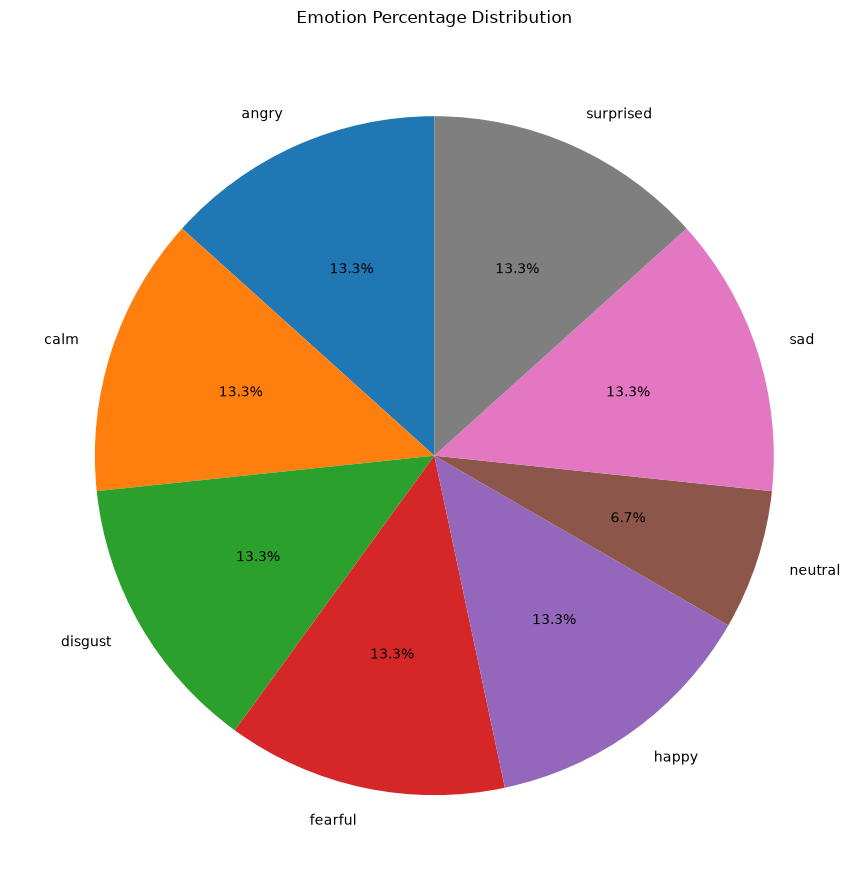

In [11]:
plt.figure(
    figsize=(9, 9)
)

plt.pie(
    emotion_counts.values,
    labels=emotion_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Emotion Percentage Distribution"
)

plt.tight_layout()

plt.show()

# 📊 Graph 3 — Actor-wise Sample Distribution

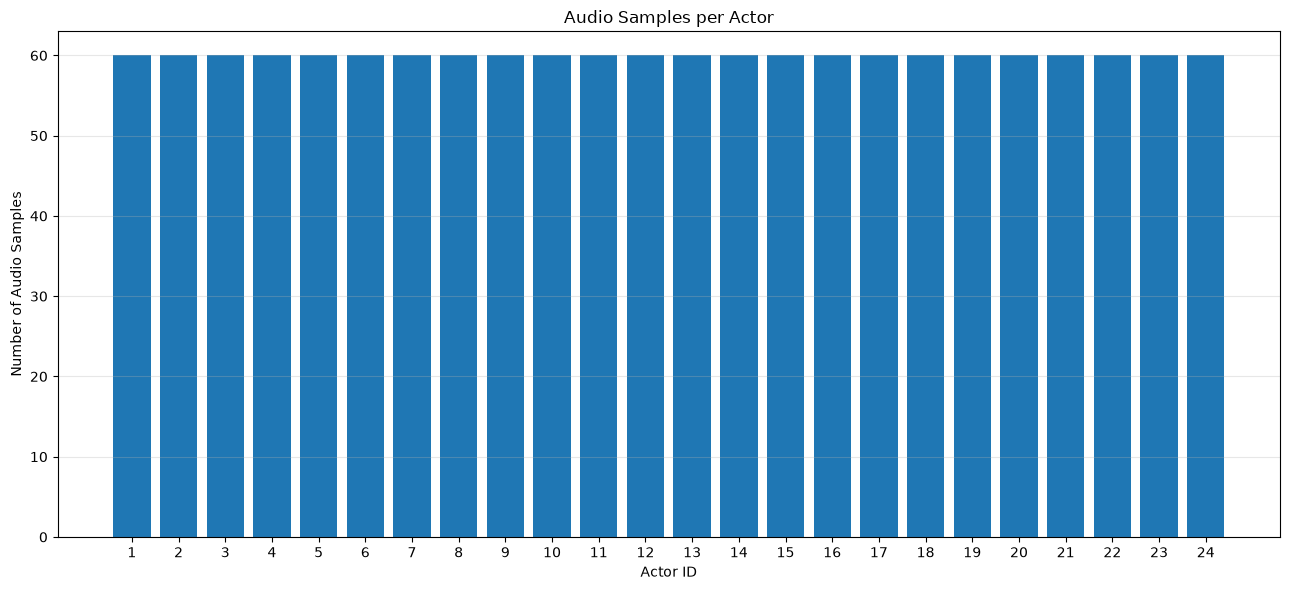

In [12]:
actor_counts = (
    df["actor"]
    .value_counts()
    .sort_index()
)

plt.figure(
    figsize=(13, 6)
)

plt.bar(
    actor_counts.index.astype(str),
    actor_counts.values
)

plt.title(
    "Audio Samples per Actor"
)

plt.xlabel(
    "Actor ID"
)

plt.ylabel(
    "Number of Audio Samples"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

# 📈 Graph 4 — Audio Duration Distribution

Audio duration is calculated from each WAV file.

This helps us understand the temporal characteristics of the dataset.

In [13]:
durations = []
sample_rates = []

print("Analyzing audio files...")

for index, file in enumerate(
    df["file_path"]
):

    try:

        info = librosa.get_duration(
            path=file
        )

        sr = librosa.get_samplerate(
            path=file
        )

        durations.append(info)
        sample_rates.append(sr)

    except Exception:

        durations.append(np.nan)
        sample_rates.append(np.nan)

    if (
        index + 1
    ) % 100 == 0:

        print(
            f"Processed {index + 1}/{len(df)}"
        )


df["duration"] = durations
df["sample_rate"] = sample_rates

print("\n✓ Audio analysis completed")

Analyzing audio files...
Processed 100/1440
Processed 200/1440
Processed 300/1440
Processed 400/1440
Processed 500/1440
Processed 600/1440
Processed 700/1440
Processed 800/1440
Processed 900/1440
Processed 1000/1440
Processed 1100/1440
Processed 1200/1440
Processed 1300/1440
Processed 1400/1440

✓ Audio analysis completed


In [14]:
print(
    df["duration"].describe()
)

count    1440.000000
mean        3.700685
std         0.336675
min         2.936313
25%         3.470188
50%         3.670375
75%         3.870563
max         5.271937
Name: duration, dtype: float64


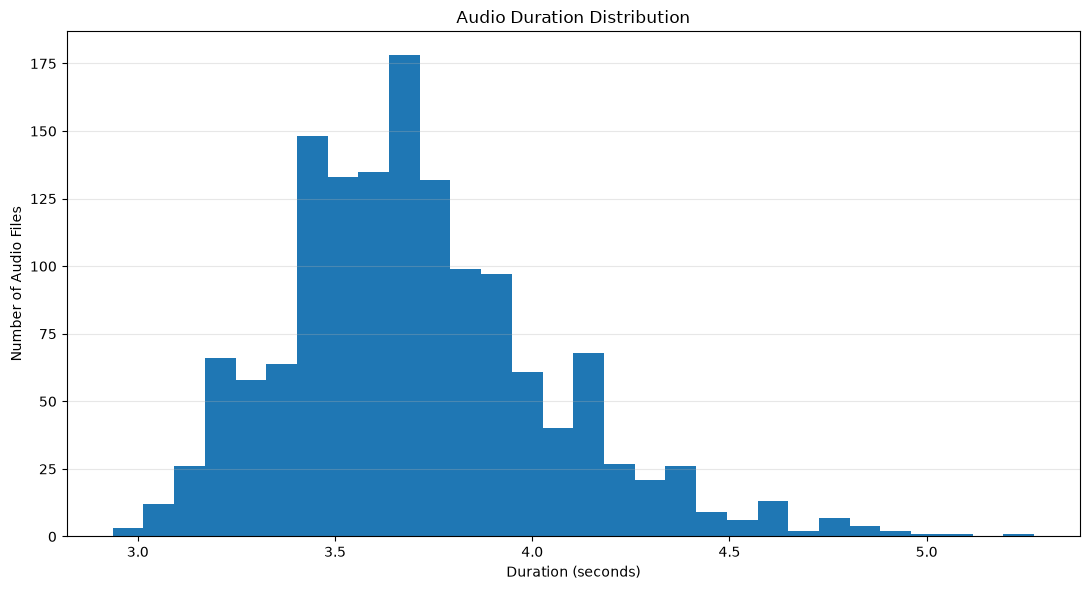

In [15]:
plt.figure(
    figsize=(11, 6)
)

plt.hist(
    df["duration"].dropna(),
    bins=30
)

plt.title(
    "Audio Duration Distribution"
)

plt.xlabel(
    "Duration (seconds)"
)

plt.ylabel(
    "Number of Audio Files"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

# 📊 Graph 5 — Sample Rate Distribution

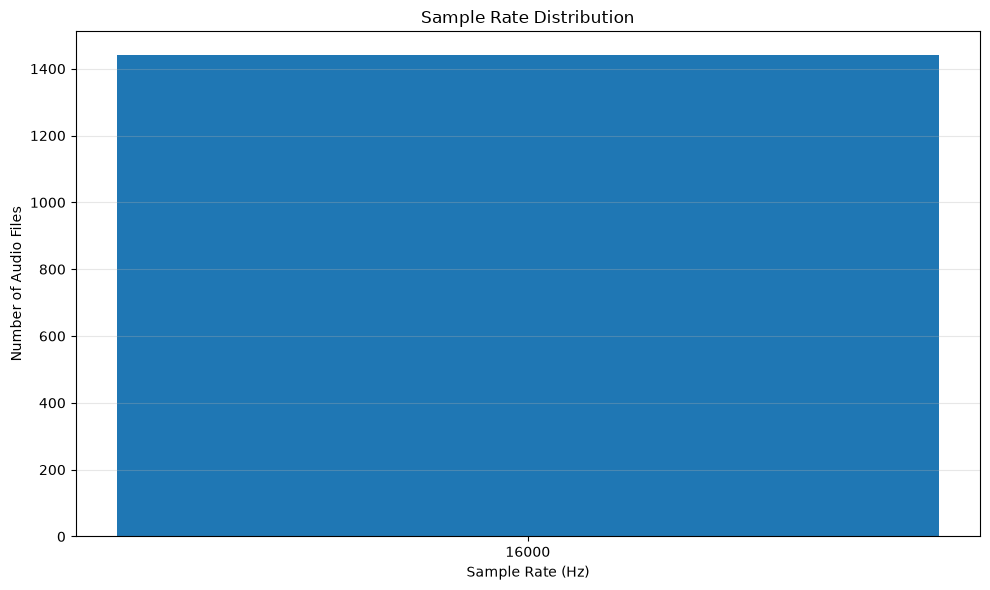

In [16]:
sample_rate_counts = (
    df["sample_rate"]
    .value_counts()
    .sort_index()
)

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    sample_rate_counts.index.astype(str),
    sample_rate_counts.values
)

plt.title(
    "Sample Rate Distribution"
)

plt.xlabel(
    "Sample Rate (Hz)"
)

plt.ylabel(
    "Number of Audio Files"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

# 🎧 4. Sample Audio

Select one audio file and inspect its basic properties.

In [17]:
sample_file = df.iloc[0]["file_path"]

audio, sr = librosa.load(
    sample_file,
    sr=None
)

emotion = df.iloc[0]["emotion"]
actor = df.iloc[0]["actor"]

print("File:")
print(sample_file)

print(
    f"\nEmotion: {emotion}"
)

print(
    f"Actor: {actor}"
)

print(
    f"Sample Rate: {sr} Hz"
)

print(
    f"Duration: {len(audio) / sr:.2f} seconds"
)

print(
    f"Samples: {len(audio):,}"
)

File:
../dataset/RAVDESS\Actor_01\03-01-01-01-01-01-01.wav

Emotion: neutral
Actor: 1
Sample Rate: 16000 Hz
Duration: 3.30 seconds
Samples: 52,853


In [18]:
display(
    Audio(
        sample_file
    )
)

# 🌊 Graph 6 — Waveform

The waveform represents the amplitude of the audio signal over time.

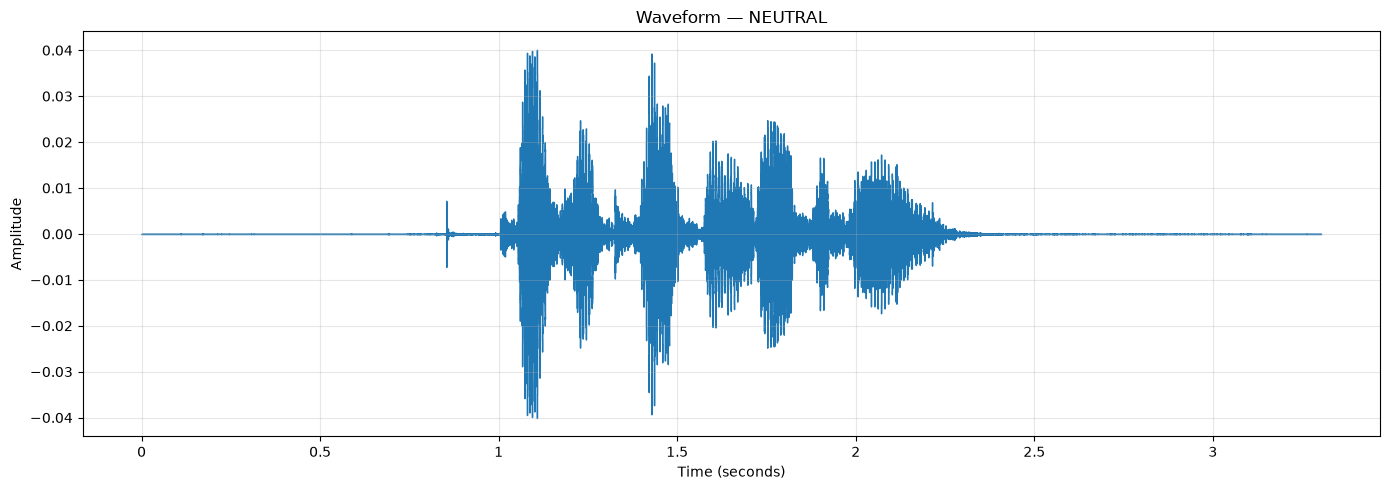

In [19]:
plt.figure(
    figsize=(14, 5)
)

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title(
    f"Waveform — {emotion.upper()}"
)

plt.xlabel(
    "Time (seconds)"
)

plt.ylabel(
    "Amplitude"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

# 🎵 Graph 7 — Mel Spectrogram

The Mel spectrogram represents the distribution of frequency
energy over time using the Mel frequency scale.

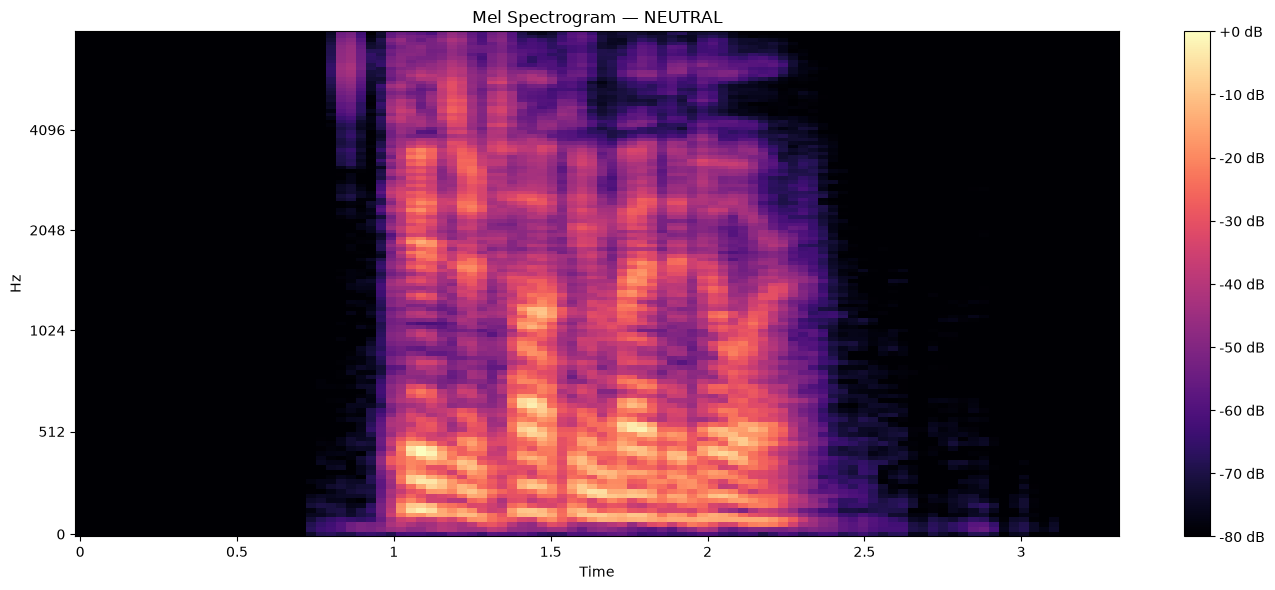

In [20]:
mel_spec = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_mels=128
)

mel_spec_db = librosa.power_to_db(
    mel_spec,
    ref=np.max
)

plt.figure(
    figsize=(14, 6)
)

librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(
    format="%+2.0f dB"
)

plt.title(
    f"Mel Spectrogram — {emotion.upper()}"
)

plt.tight_layout()

plt.show()

# 🎼 Graph 8 — MFCC Visualization

MFCCs are commonly used as compact representations of
speech characteristics and will be used later for model training.

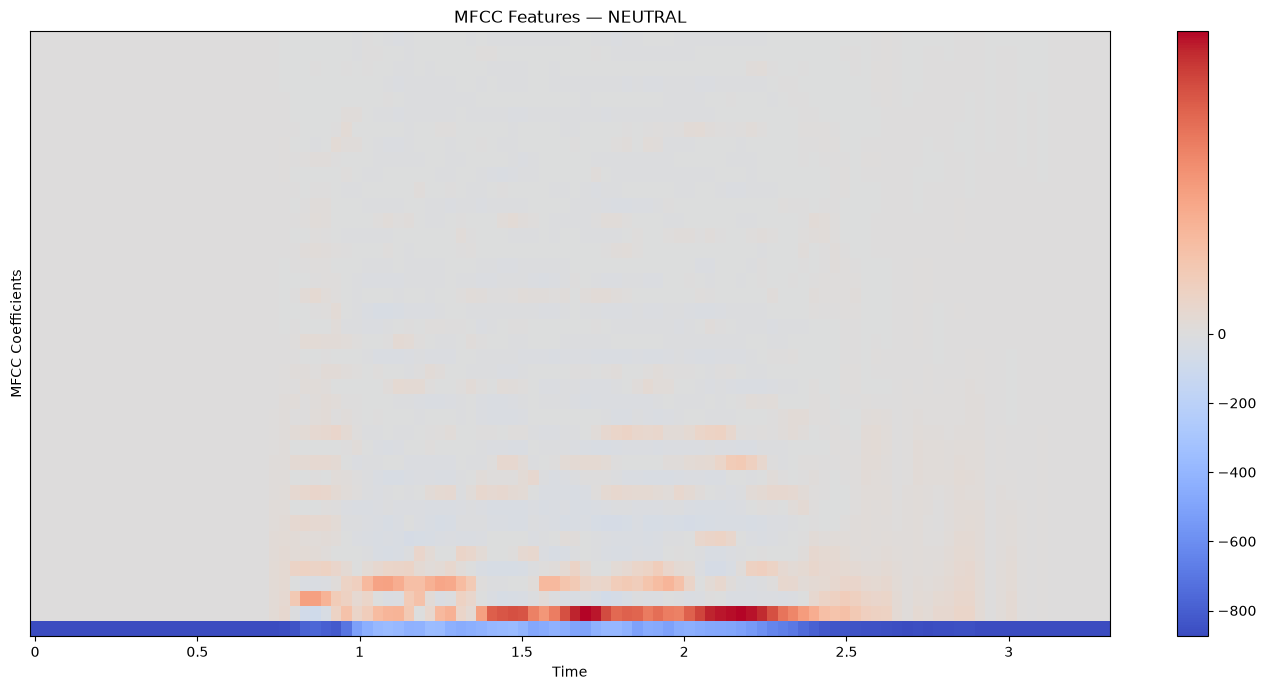

MFCC shape: (40, 104)


In [21]:
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=40
)

plt.figure(
    figsize=(14, 7)
)

librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sr
)

plt.colorbar()

plt.title(
    f"MFCC Features — {emotion.upper()}"
)

plt.ylabel(
    "MFCC Coefficients"
)

plt.xlabel(
    "Time"
)

plt.tight_layout()

plt.show()

print(
    "MFCC shape:",
    mfcc.shape
)

# 🌊 Graph 9 — Waveform Comparison Across Emotions

To visually compare speech patterns, one sample from
each emotion is displayed.

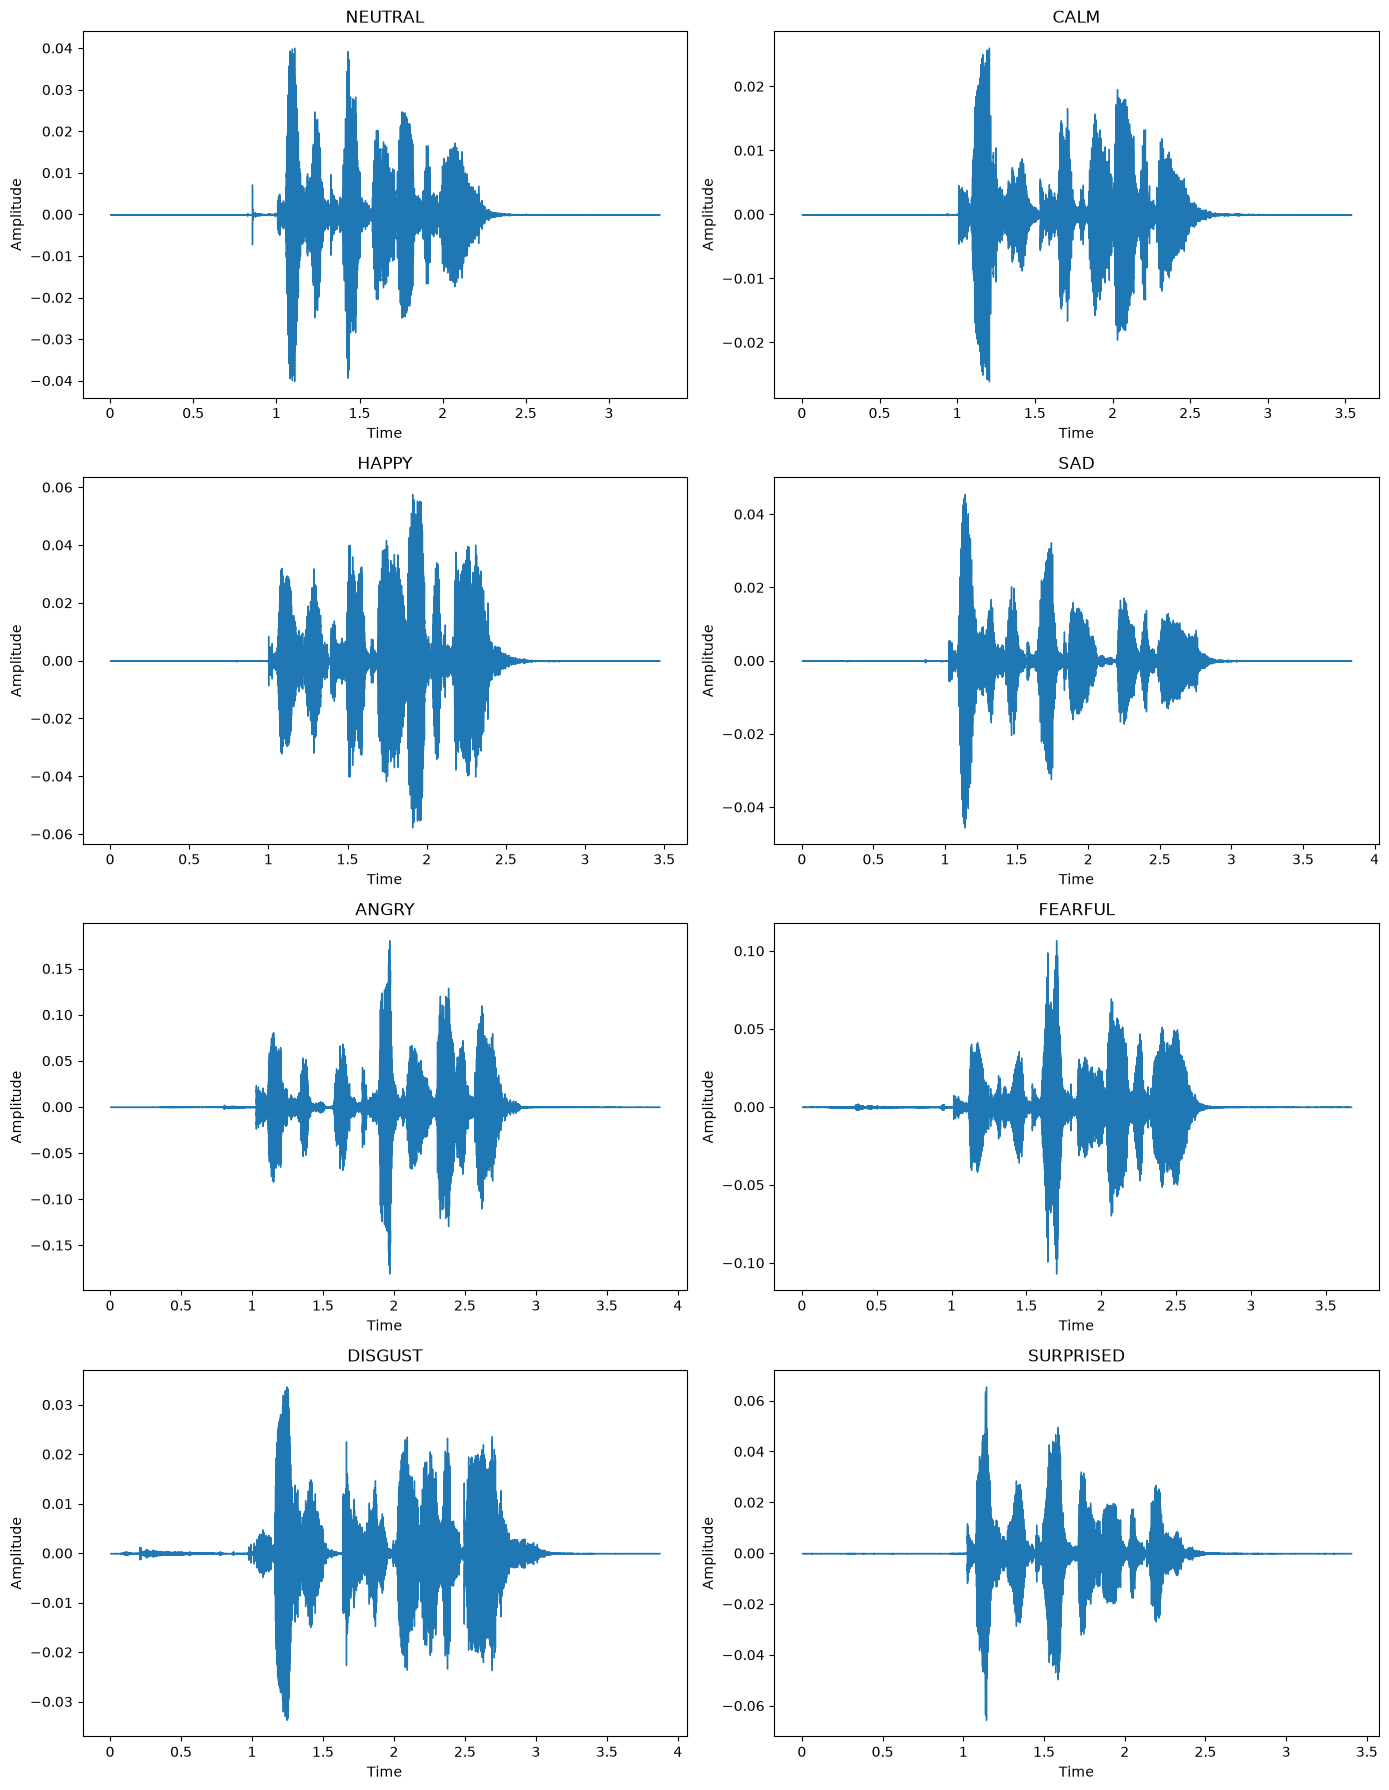

In [22]:
selected_emotions = [
    "neutral",
    "calm",
    "happy",
    "sad",
    "angry",
    "fearful",
    "disgust",
    "surprised"
]

plt.figure(
    figsize=(14, 18)
)

for position, emotion_name in enumerate(
    selected_emotions,
    start=1
):

    emotion_rows = df[
        df["emotion"] == emotion_name
    ]

    if len(emotion_rows) == 0:
        continue

    file = emotion_rows.iloc[0]["file_path"]

    signal, signal_sr = librosa.load(
        file,
        sr=None
    )

    ax = plt.subplot(
        4,
        2,
        position
    )

    librosa.display.waveshow(
        signal,
        sr=signal_sr,
        ax=ax
    )

    ax.set_title(
        emotion_name.upper()
    )

    ax.set_xlabel(
        "Time"
    )

    ax.set_ylabel(
        "Amplitude"
    )

plt.tight_layout()

plt.show()

# 🎵 Graph 10 — Mel Spectrogram Comparison Across Emotions

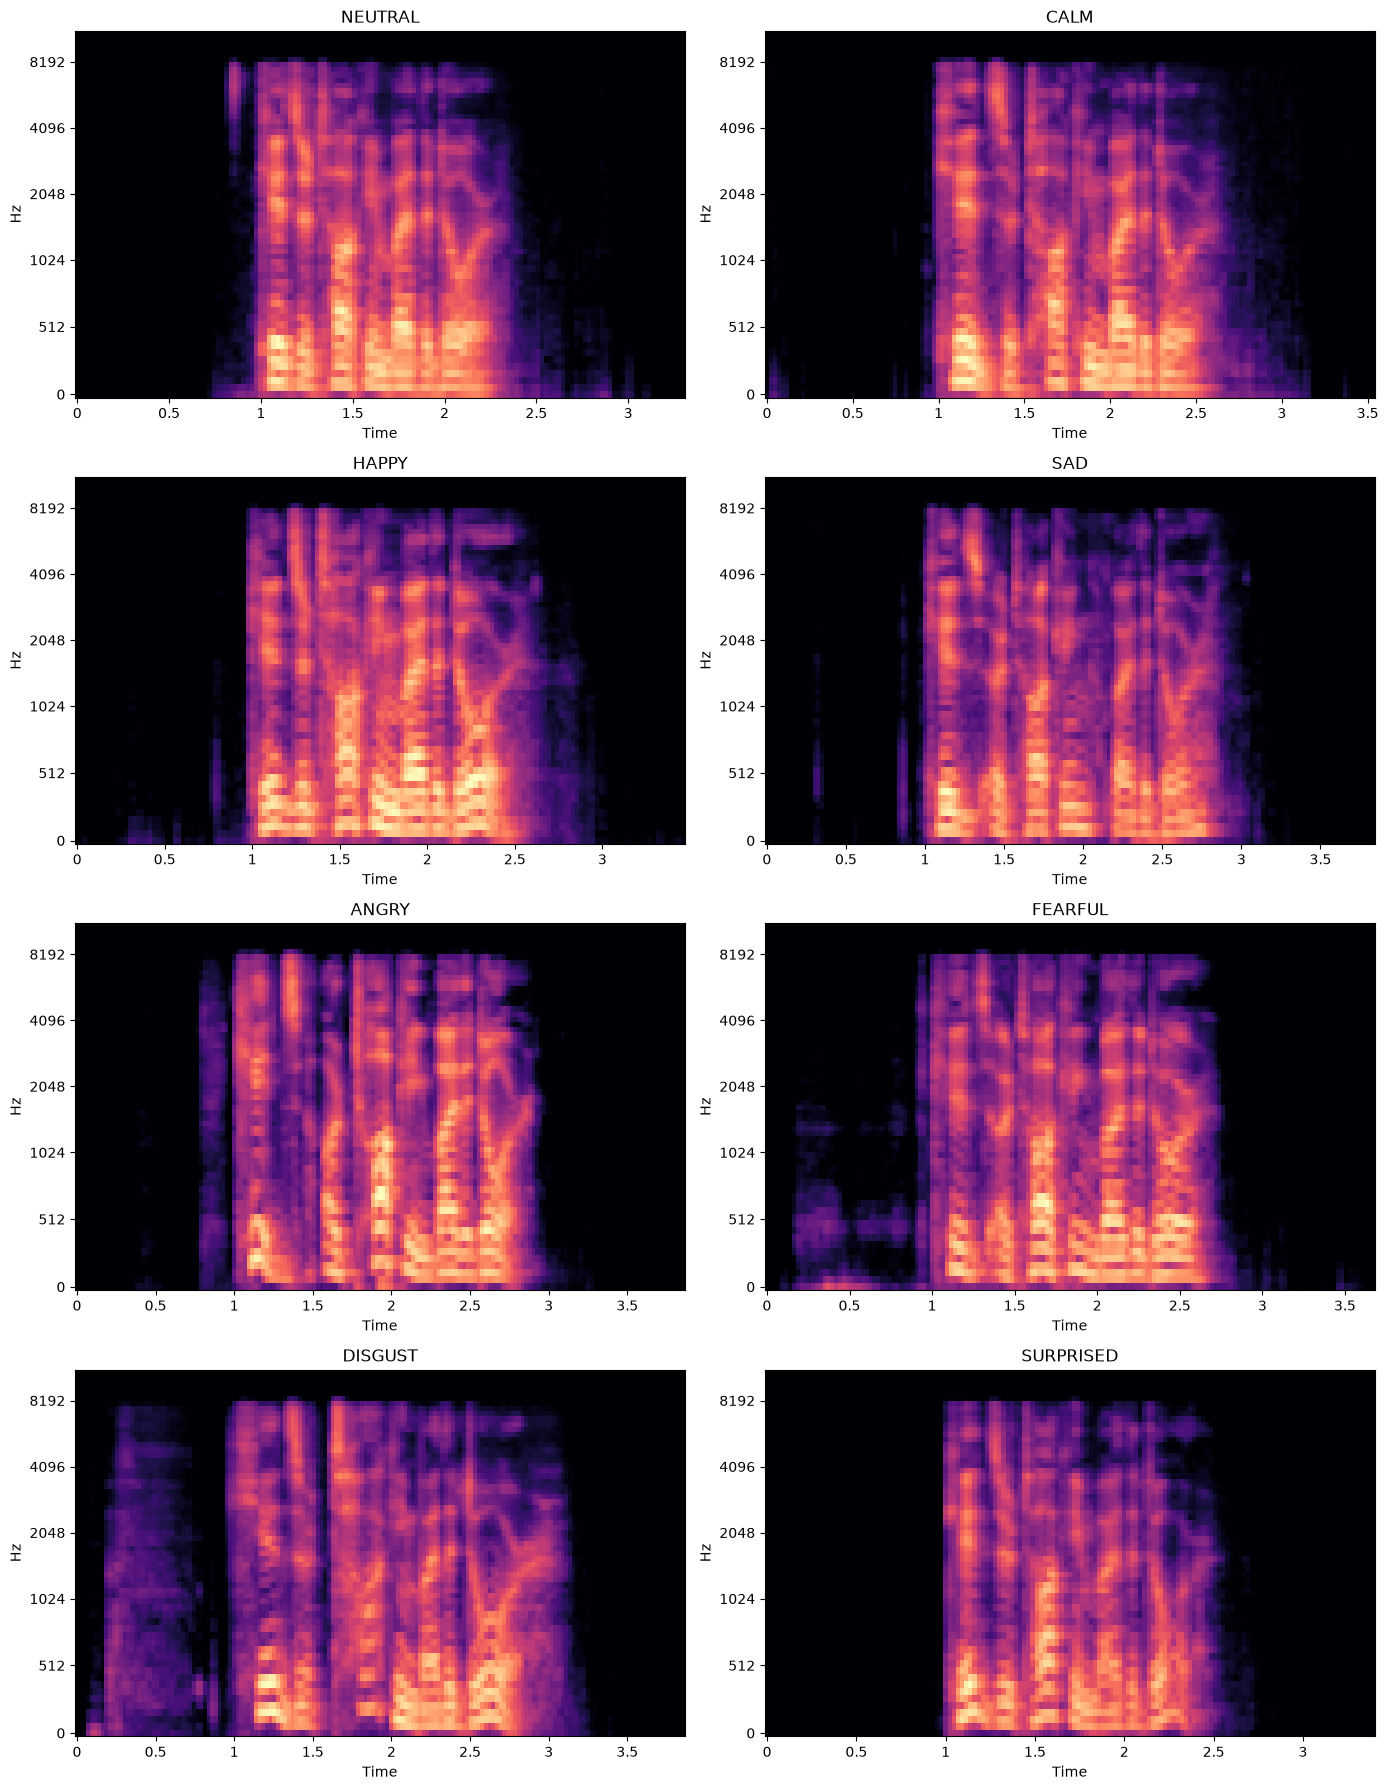

In [24]:
plt.figure(
    figsize=(14, 18)
)

for position, emotion_name in enumerate(
    selected_emotions,
    start=1
):

    emotion_rows = df[
        df["emotion"] == emotion_name
    ]

    if len(emotion_rows) == 0:
        continue

    file = emotion_rows.iloc[0]["file_path"]

    signal, signal_sr = librosa.load(
        file,
        sr=22050
    )

    mel = librosa.feature.melspectrogram(
        y=signal,
        sr=signal_sr,
        n_mels=64
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    ax = plt.subplot(
        4,
        2,
        position
    )

    img = librosa.display.specshow(
        mel_db,
        sr=signal_sr,
        x_axis="time",
        y_axis="mel",
        ax=ax
    )

    ax.set_title(
        emotion_name.upper()
    )

plt.tight_layout()

plt.show()

# 📋 5. Final Dataset Summary

In [25]:
summary = pd.DataFrame({
    "Metric": [
        "Total Audio Files",
        "Number of Emotions",
        "Number of Actors",
        "Average Duration",
        "Minimum Duration",
        "Maximum Duration",
        "Average Sample Rate"
    ],

    "Value": [
        len(df),
        df["emotion"].nunique(),
        df["actor"].nunique(),
        f"{df['duration'].mean():.2f} sec",
        f"{df['duration'].min():.2f} sec",
        f"{df['duration'].max():.2f} sec",
        f"{df['sample_rate'].mean():.0f} Hz"
    ]
})

summary

,Metric,Value
0,Total Audio Files,1440
1,Number of Emotions,8
2,Number of Actors,24
3,Average Duration,3.70 sec
4,Minimum Duration,2.94 sec
5,Maximum Duration,5.27 sec
6,Average Sample Rate,16000 Hz


# Conclusion

The exploratory analysis provided a detailed understanding
of the RAVDESS speech emotion dataset.

We analyzed:

- Dataset size
- Emotion classes
- Emotion distribution
- Emotion percentages
- Actor-wise distribution
- Audio duration
- Sample rate
- Sample audio
- Waveform
- Mel spectrogram
- MFCC features
- Waveform comparison across emotions
- Spectrogram comparison across emotions

The MFCC representation will be used in the next stage for
feature extraction and model preparation.

